# Image Classification Model Using an Inbuilt Dataset

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

2025-06-04 20:27:33.117060: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-04 20:27:34.475100: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-04 20:27:35.161839: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749049055.880435   45664 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749049056.059427   45664 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749049062.145860   45664 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

# Load the Inbuilt MNIST Dataset

In [2]:
# Load MNIST dataset from TensorFlow/Keras
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Reshape data to fit the model: (samples, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0


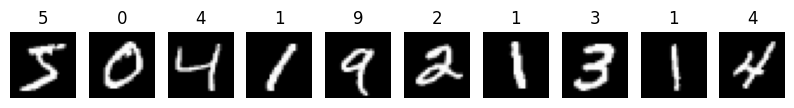

In [3]:
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.title(str(y_train[i]))
plt.show()

In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


/home/bukya-jagadish-naik/Desktop/CodTechIntern/myvenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-04 20:28:08.643073: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [6]:
history = model.fit(X_train, y_train, epochs=5, 
                    validation_data=(X_test, y_test))


Epoch 1/5


2025-06-04 20:28:09.983383: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 28ms/step - accuracy: 0.9051 - loss: 0.3145 - val_accuracy: 0.9825 - val_loss: 0.0563
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9839 - loss: 0.0508 - val_accuracy: 0.9854 - val_loss: 0.0458
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9898 - loss: 0.0338 - val_accuracy: 0.9890 - val_loss: 0.0348
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 89s 34ms/step - accuracy: 0.9924 - loss: 0.0237 - val_accuracy: 0.9889 - val_loss: 0.0330
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 32ms/step - accuracy: 0.9950 - loss: 0.0167 - val_accuracy: 0.9880 - val_loss: 0.0372


In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.3f}")


313/313 - 4s - 11ms/step - accuracy: 0.9880 - loss: 0.0372
Test accuracy: 0.988


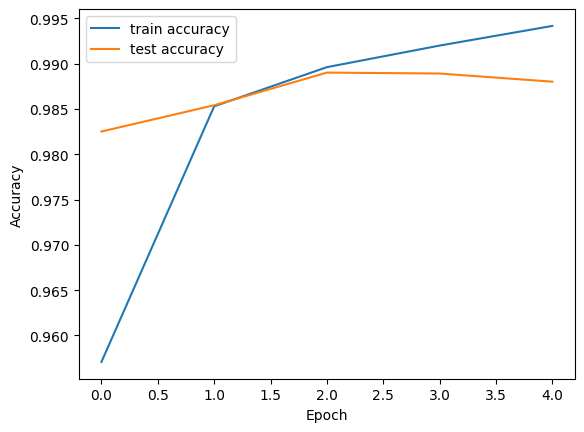

In [8]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


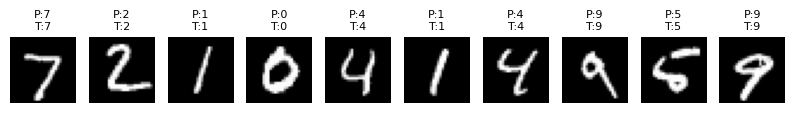

In [9]:
import numpy as np

predictions = model.predict(X_test)
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    plt.title(f"P:{pred_label}\nT:{true_label}", fontsize=8)
plt.show()
